This notebook demonstrates how to solve a finite-horizon Linear Quadratic Regulator (LQR) problem using a Gaussian Factor Graph in GTSAM. The goal is to minimize a quadratic cost w.r.t. dynamics constraints over a linear dynamical system using factor-graph-based optimization. The results are compared against results from classical Riccati equations. Adapted from https://gtsam.org/2019/11/07/lqr-control.html

Author(s): Zhouyu Zhang

GTSAM Copyright 2010-2025, Georgia Tech Research Corporation, Atlanta, Georgia 30332-0415 All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [1]:
%pip install --quiet gtsam-develop

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import gtsam
from gtsam import symbol

In [3]:
# Define system dynamics: x_{k+1} = A x_k + B u_k
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])
B = np.array([[0.0],
              [1.0]])

# Define cost matrices: minimize sum of (xᵀQx + uᵀRu)
Q = np.eye(2)
R = np.array([[1.0]])


In [14]:
N = 4
# Cost factors: L such that Q = LᵀL
Lx = np.linalg.cholesky(Q)
Lu = np.linalg.cholesky(R)

# Create a Gaussian factor graph for the linear-quadratic problem
graph = gtsam.GaussianFactorGraph()
initial_values = gtsam.Values()

# Set initial state: x_0 = [0, 1]^T, add a strong prior factor to fix the initial state
x0 = np.array([0.0, 1.0])
prior_noise = gtsam.noiseModel.Isotropic.Sigma(2, 1e-20)
graph.add(gtsam.JacobianFactor(symbol('x', 0), np.eye(2), x0, prior_noise))

# Cost + dynamics
for k in range(N):
    xk = symbol('x', k)
    uk = symbol('u', k)

    # Cost factor: x_k^T Q x_k
    graph.add(gtsam.JacobianFactor(xk, Lx, np.zeros(2), gtsam.noiseModel.Unit.Create(2)))

    # Cost factor: u_k^T R u_k
    graph.add(gtsam.JacobianFactor(uk, Lu, np.zeros(1), gtsam.noiseModel.Unit.Create(1)))

    # Dynamics hard constraint factor: x_{k+1} = A x_k + B u_k
    if k < N:
        xk1 = symbol('x', k + 1)
        graph.add(gtsam.JacobianFactor(
            xk1, np.eye(2),
            xk, -A,
            uk, -B,
            np.zeros((2, 1)),
            gtsam.noiseModel.Diagonal.Sigmas(np.zeros(2))  # hard constraint
        ))

# Terminal cost: x_N^T Q x_N
xN = symbol('x', N)
graph.add(gtsam.JacobianFactor(xN, Lx, np.zeros(2), gtsam.noiseModel.Unit.Create(2)))


array([[ 0.        ,  1.        ],
       [ 1.        , -0.23834197],
       [ 0.76165803, -0.35233161],
       [ 0.40932642, -0.21761658]])

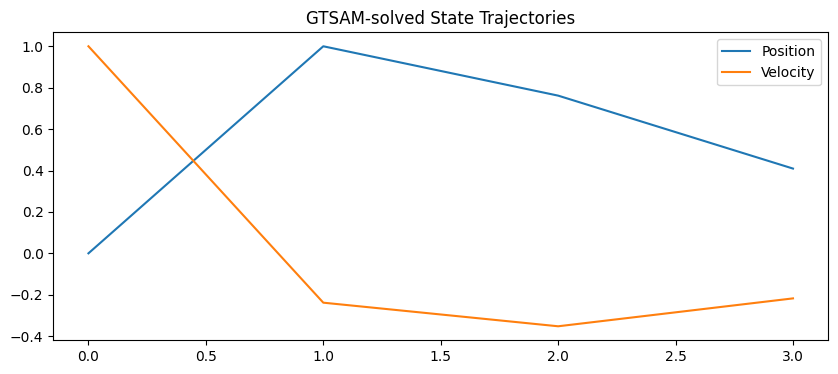

In [15]:
# Solve the factor graph and retrieve the results
result = graph.optimize()

states = []
controls = []
for k in range(N):
    xk = symbol('x', k)
    uk = symbol('u', k)
    states.append(result.at(xk))
    controls.append(result.at(uk))


states = np.array(states)
controls = np.array(controls)

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(states[:, 0], label='Position')
plt.plot(states[:, 1], label='Velocity')
plt.title('GTSAM-solved State Trajectories')
plt.legend()
states


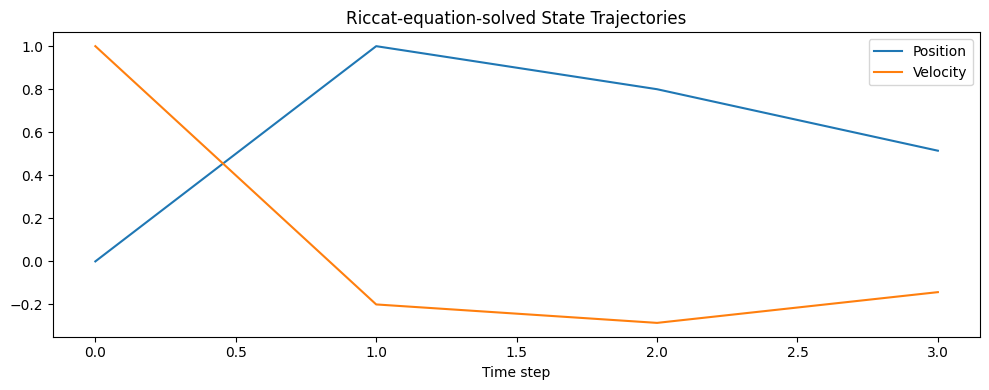

States:
 [[ 0.          1.        ]
 [ 1.         -0.2       ]
 [ 0.8        -0.28571429]
 [ 0.51428571 -0.14285714]]
Controls:
 [[-1.2       ]
 [-0.08571429]
 [ 0.14285714]]


In [11]:
# Solve the LQR problem with the classical Riccati equation method
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are

# System definition
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])
B = np.array([[0.0],
              [1.0]])
Q = np.eye(2)
R = np.array([[1.0]])
x0 = np.array([0.0, 1.0])
N = 3  # Horizon length

# Backward Riccati recursion to compute K_t
P = Q.copy()  # Terminal cost
K_list = []

for _ in range(N):
    S = R + B.T @ P @ B
    K = np.linalg.solve(S, B.T @ P @ A)  # K = (R + Bᵀ P B)⁻¹ Bᵀ P A
    K_list.insert(0, K)  # prepend to use forward later
    P = Q + A.T @ P @ A - A.T @ P @ B @ K  # update P for next step

# Forward rollout of trajectory
x = x0.reshape(-1, 1)
states = [x.flatten()]
controls = []

for K in K_list:
    u = -K @ x
    controls.append(u.flatten())
    x = A @ x + B @ u
    states.append(x.flatten())

states = np.array(states)
controls = np.array(controls)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(states[:, 0], label='Position')
plt.plot(states[:, 1], label='Velocity')
plt.title('Riccat-equation-solved State Trajectories')
plt.xlabel('Time step')
plt.legend()


plt.tight_layout()
plt.show()

# Optional: print values
print("States:\n", states)
print("Controls:\n", controls)
